This notebook replicates the figures shown in manuscript. Sections are separated by figure number.

In [1]:
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import pickle as pkl
import skimage
import yaml
from typing import Union, Optional, Type, Tuple, List, Dict
import sys
from skimage.color import label2rgb
import json
# import nrrd

import pandas as pd
import seaborn as sns

# Project Root
# used for searching packages and functions
# TODO: enter your project root dir here (the one containing multiTAP)
ROOT_DIR = '/project/Xie_Lab/zgu/xiao_multiplex/multiTAP'

sys.path.append(ROOT_DIR)
sys.path.append(os.path.join(ROOT_DIR, 'image_cytof'))
from cytof.hyperion_preprocess import cytof_read_data_roi
from cytof.utils import save_multi_channel_img, check_feature_distribution
from cytof.classes import CytofImageTiff
from cytof.classes import CytofCohort

/project/Xie_Lab/zgu/conda_stuff/envs/cytof-shared/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Figure 1
Marker greyscale and pseudoRGB visualization.


In [2]:
# dir to save figs
BASE_FIG_DIR = "/project/Xie_Lab/zgu/xiao_multiplex/figures"

## Figure 1 image setup
Load the IMC ROI and define marker channels used for the Figure 1 channel panels.


In [3]:
class SetParameters():
    def __init__(self, 
                 filename: str, 
                 outdir: str, 
                 label_marker_file: str, 
                 slide: Optional[str] = 'slide1', 
                 roi: Optional[str] = 'roi1', 
                 quality_control_thres: Optional[int] = 50,
                 channels_remove: Optional[List] = None, 
                 channels_dict: Optional[Dict] = None,
                 use_membrane: Optional[bool] = True,
                 cell_radius: Optional[int] = 5, 
                 normalize_qs: Optional[List[int]] = [75, 99]):
        
        self.filename = filename
        self.outdir   = outdir
        self.slide    = slide
        self.roi      = roi
        self.quality_control_thres = quality_control_thres
        self.label_marker_file     = label_marker_file
        self.channels_remove = channels_remove if channels_remove is not None else []
        self.channels_dict   = channels_dict if channels_dict is not None else {}
        self.use_membrane    = use_membrane
        self.cell_radius     = cell_radius
        self.normalize_qs    = normalize_qs


In [4]:
params = SetParameters(
    #TODO: input IMC file path here 
    # IMC file
    filename='/project/Xie_Lab/zgu/xiao_multiplex/breast_cancer_data_Basel/OMEandSingleCellMasks/OMEnMasks/ome/ome/BaselTMA_SP43_25.8kx22ky_10500x6500_8_20170928_114_115_X4Y8_262_a0_full.tiff',
    
    # Opal file
    # filename='/project/DPDS/Xiao_lab/shared/deep_learning_SW_RR/cytof/additional_opal_data/TP00899-T0-S1-1_Scan1_reg_5000_8000.tiff',
    
    outdir="../test_out/tiffs/single_roi", # optional
    slide="BaselTMA_SP43_25.8kx22ky", # for naming purposes
    roi="114_115_X4Y8_262", # for naming purposes

    label_marker_file = "./supplemental/markers_labels_BrCa.txt", # locate corresponding `markers_labels_X.txt`
)

To generate markers_labels.txt, you could 1) check staining panels from the original publication, and 2) if .mcd files are shared, labels and markers could be extracted. Reference `tutorial-mcd-explore.ipynb`.

In [5]:
# read slide into class object
cytof_img, _ = cytof_read_data_roi(params.filename, slide=params.slide, roi=params.roi)

# set the channels and markers
labels_markers = yaml.load(open(params.label_marker_file, "rb"), Loader=yaml.Loader)
cytof_img.set_markers(**labels_markers)

In [6]:
# remove unwanted channels
channels_remove = ['nan1-nan1', 'nan2-nan2', 'nan3-nan3', 'nan4-nan4', 'nan5-nan5']
setattr(params, "channels_remove", channels_remove)

In [7]:
if hasattr(params,"channels_remove") and len(params.channels_remove) > 0:
    cytof_img.remove_special_channels(params.channels_remove)
    
    print("Original list of channels: \n{}".format(', '.join(cytof_img.raw_channels)))
    print("\nUpdated list of channels: \n{}".format(', '.join(cytof_img.channels)))


Original list of channels: 
ArgonDimers-Ar80, RutheniumTetroxide-Ru96, RutheniumTetroxide-Ru98, RutheniumTetroxide-Ru99, RutheniumTetroxide-Ru100, RutheniumTetroxide-Ru101, RutheniumTetroxide-Ru102, RutheniumTetroxide-Ru104, Histone H3-In113, nan1-nan1, nan2-nan2, Histone H3-La139, Cytokeratin 5-Pr141, Fibronectin-Nd142, Cytokeratin 19-Nd143, Cytokeratin 8or18-Nd144, Twist-Nd145, CD68-Nd146, Keratin 14 (KRT14)-Sm147, SMA-Nd148, Vimentin-Sm149, c-Myc-Nd150, c-erbB-2 - Her2-Eu151, CD3-Sm152, Histone H3-Eu153, Erk1or2-Sm154, Slug-Gd155, Rabbit IgG H L-Gd156, Progesterone Receptor AorB-Gd158, p53-Tb159, CD44-Gd160, EpCAM-Dy161, CD45-Dy162, GATA3-Dy163, CD20-Dy164, b-Catenin-Ho165, Carbonic Anhydrase IX-Er166, undefined-Er167, Ki-67-Er168, EGFR-Tm169, S6-Er170, Sox9-Yb171, vWF-CD31-Yb172, mTOR-Yb173, Cytokeratin 7-Yb174, pan Cytokeratin-Keratin Epithelial-Lu175, cleaved PARP-Cleaved Caspase3-Yb176, DNA1-Ir191, DNA2-Ir193, nan3-nan3, nan4-nan4, nan5-nan5

Updated list of channels: 
ArgonDime

## Define special channel(s)
Define nuclei channel, optionally, define membrane channel, to get prepared for nuclei and cells segmentation.  

In [8]:
#TODO: change accordingly
channel_dict = {
        'nuclei': ['DNA1-Ir191', 'DNA2-Ir193'],
        'membrane': ['Vimentin-Sm149', 'c-erbB-2 - Her2-Eu151', 'pan Cytokeratin-Keratin Epithelial-Lu175', 
                     'CD44-Gd160','Fibronectin-Nd142'], 
    }

setattr(params, 'channel_dict', channel_dict)

In [9]:
channels_ = cytof_img.channels[:]

# define special channels (if desired)
channels_rm = cytof_img.define_special_channels(params.channel_dict, rm_key='nuclei')

# remove unwanted channels (if desired)
cytof_img.remove_special_channels(channels_rm)



print("\nList of channels before defining special channel(s): \n{}".format(', '.join(channels_)))
print("\nUpdated list of channels after defining special channel(s): \n{}".format(', '.join(cytof_img.channels)))

print("Manually defined channels:", cytof_img.defined_channels)



List of channels before defining special channel(s): 
ArgonDimers-Ar80, RutheniumTetroxide-Ru96, RutheniumTetroxide-Ru98, RutheniumTetroxide-Ru99, RutheniumTetroxide-Ru100, RutheniumTetroxide-Ru101, RutheniumTetroxide-Ru102, RutheniumTetroxide-Ru104, Histone H3-In113, Histone H3-La139, Cytokeratin 5-Pr141, Fibronectin-Nd142, Cytokeratin 19-Nd143, Cytokeratin 8or18-Nd144, Twist-Nd145, CD68-Nd146, Keratin 14 (KRT14)-Sm147, SMA-Nd148, Vimentin-Sm149, c-Myc-Nd150, c-erbB-2 - Her2-Eu151, CD3-Sm152, Histone H3-Eu153, Erk1or2-Sm154, Slug-Gd155, Rabbit IgG H L-Gd156, Progesterone Receptor AorB-Gd158, p53-Tb159, CD44-Gd160, EpCAM-Dy161, CD45-Dy162, GATA3-Dy163, CD20-Dy164, b-Catenin-Ho165, Carbonic Anhydrase IX-Er166, undefined-Er167, Ki-67-Er168, EGFR-Tm169, S6-Er170, Sox9-Yb171, vWF-CD31-Yb172, mTOR-Yb173, Cytokeratin 7-Yb174, pan Cytokeratin-Keratin Epithelial-Lu175, cleaved PARP-Cleaved Caspase3-Yb176, DNA1-Ir191, DNA2-Ir193

Updated list of channels after defining special channel(s): 
Arg

## Figure 1 marker channel visualization
Greyscale marker panels and pseudoRGB composite.


Visualizing channels: CD68-Nd146, SMA-Nd148, EGFR-Tm169, Sox9-Yb171
Visualizing... 
CD68-Nd146 in red
SMA-Nd148 in green
EGFR-Tm169 in blue
Sox9-Yb171 in cyan



/project/Xie_Lab/zgu/xiao_multiplex/multiTAP/image_cytof/cytof/classes.py:274: UserWarning: Visualizing more than 3 channels the same time results in deteriorated visualization.                 It is not recommended!
  warnings.warn(


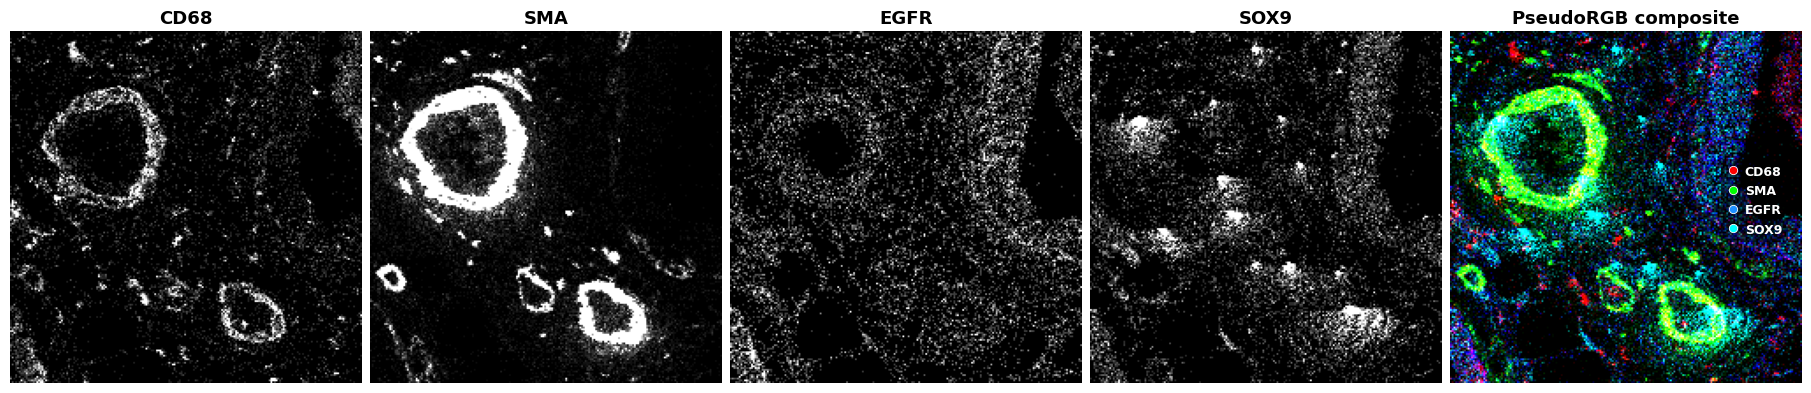

In [10]:
%matplotlib inline

# choosing a subsection
vis_range = {
    'h0': 300,
    'h1': 500,
    'w0': 200,
    'w1': 400,
}

vis_channels_RGB = ['CD68-Nd146', 'SMA-Nd148', 'EGFR-Tm169', 'Sox9-Yb171']
marker_labels = {
    'CD68-Nd146': 'CD68',
    'SMA-Nd148': 'SMA',
    'EGFR-Tm169': 'EGFR',
    'Sox9-Yb171': 'SOX9',
}

pseudoRGB, quantiles, color_pool = cytof_img.visualize_channels(channel_names=vis_channels_RGB, visualize=False)

crop = np.s_[vis_range['h0']:vis_range['h1'], vis_range['w0']:vis_range['w1']]
channel_ids = [cytof_img.channels.index(channel) for channel in vis_channels_RGB]

from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 5, figsize=(18, 4), constrained_layout=True)

for ax, channel, channel_id, quantile in zip(axes[:4], vis_channels_RGB, channel_ids, quantiles):
    marker_gray = np.clip(cytof_img.image[..., channel_id] / quantile, 0, 1)
    ax.imshow(marker_gray[crop], cmap='gray', vmin=0, vmax=1)
    ax.set_title(marker_labels[channel], fontsize=13, fontweight='bold')
    ax.axis('off')

axes[4].imshow(pseudoRGB[crop])
axes[4].set_title('PseudoRGB composite', fontsize=13, fontweight='bold')
axes[4].axis('off')

legend_entries = [
    ('CD68', 'red'),
    ('SMA', 'lime'),
    ('EGFR', 'dodgerblue'),
    ('SOX9', 'cyan'),
]
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='None', markersize=6,
           markerfacecolor=color, markeredgecolor='white', markeredgewidth=0.6,
           label=label)
    for label, color in legend_entries
]
legend = axes[4].legend(handles=legend_handles, loc='center right', bbox_to_anchor=(0.98, 0.52),
                        frameon=True, facecolor='black', edgecolor='none', framealpha=0.45,
                        fontsize=9, handlelength=1.0, handletextpad=0.4, borderpad=0.5,
                        labelcolor='white')
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.show()


# Figure 2
## Nuclei and cells segmentation
With the nuclei channel (and membrane channel) defined, nuclei and cells segmentation can be easily done with the class method `get_seg`.  
`cytof_img.get_seg()`


True
Nuclei segmentation...


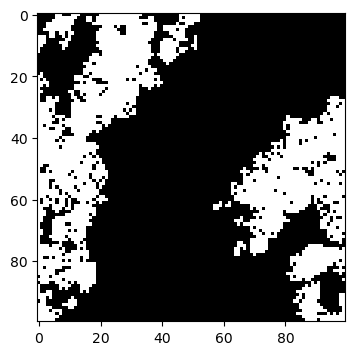

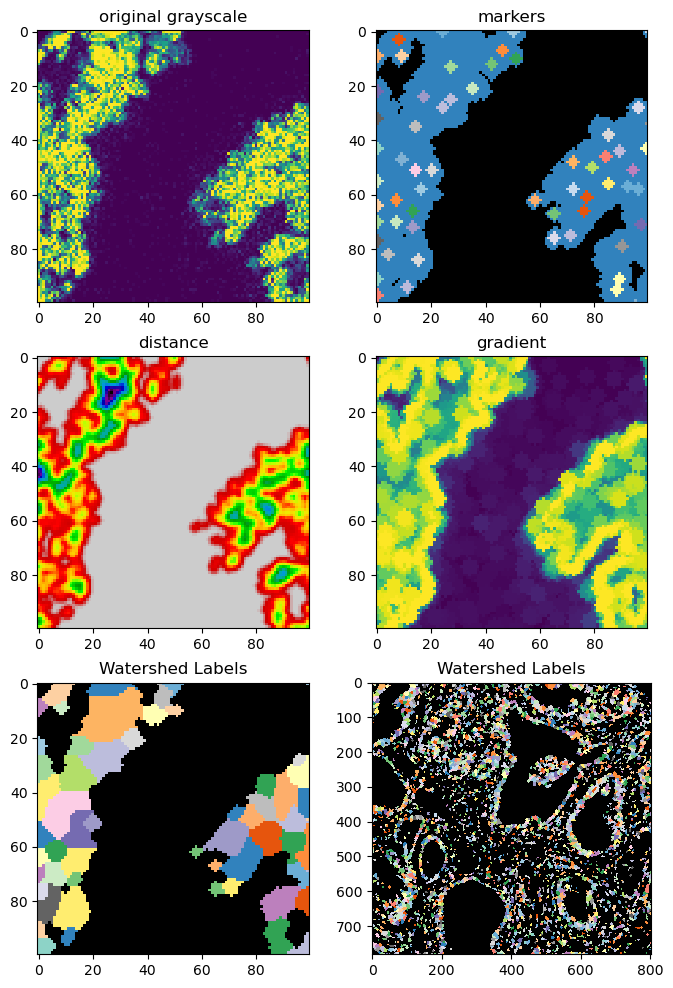

Cell segmentation...


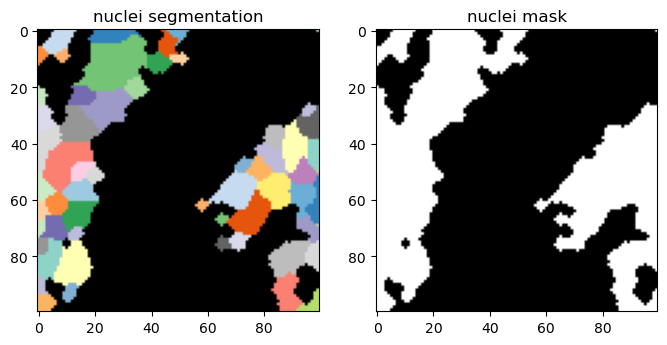

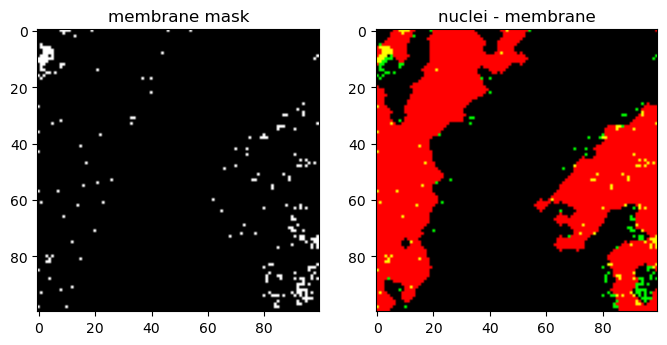

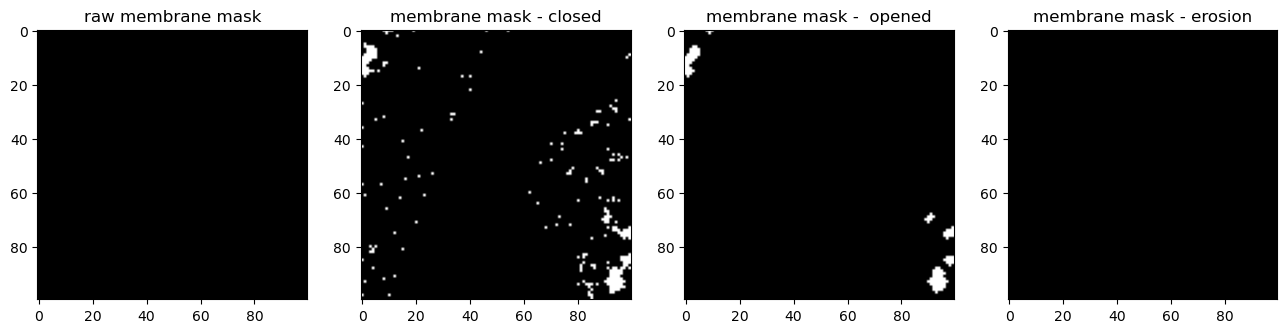

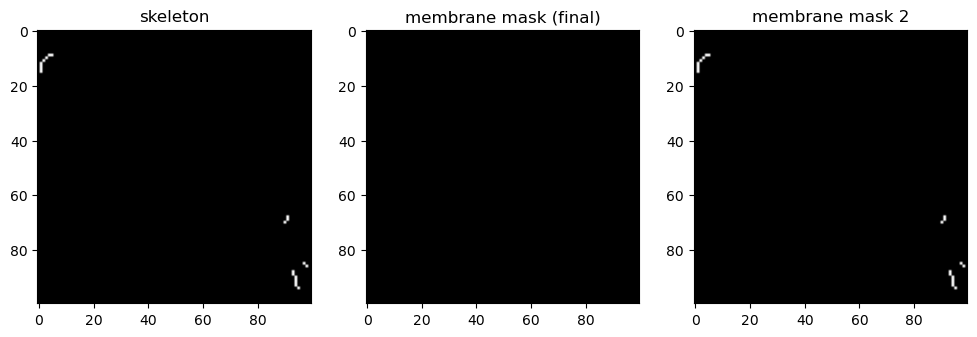

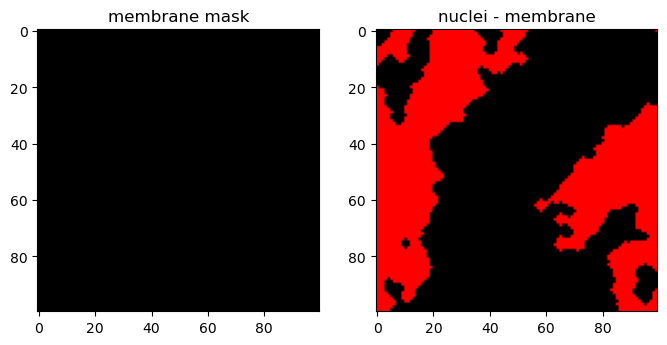

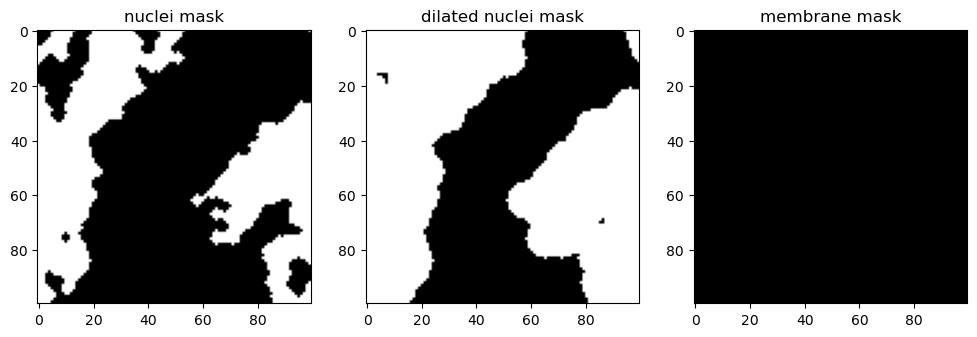

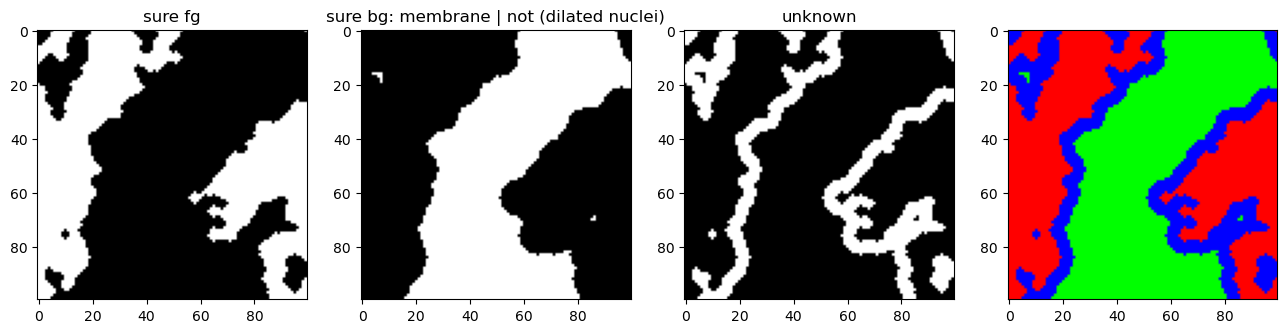

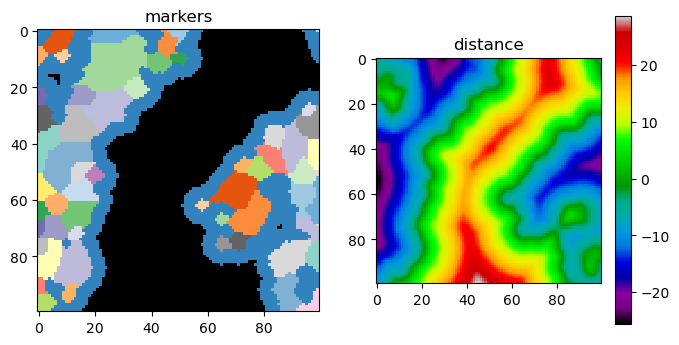

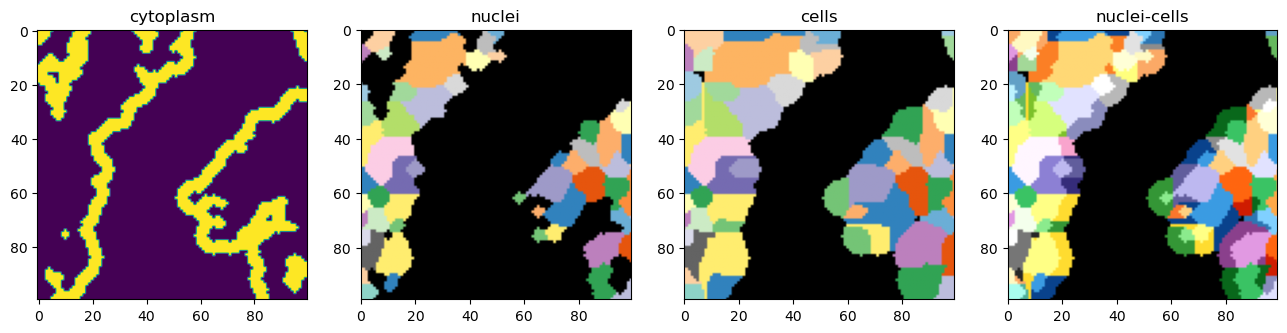

In [11]:
%matplotlib inline

print(params.use_membrane)
nuclei_seg, cell_seg = cytof_img.get_seg(use_membrane=params.use_membrane, 
                                         radius=params.cell_radius, # 10
                                         show_process=True)

## Figure 2A, 2B
Visualizations of nuclei and cells segmentation

Visualizing channels: nuclei, membrane
Visualizing... 
nuclei in red
membrane in green

Visualizing... 
nuclei in red
membrane in green

nuclei boundary marked by yellow


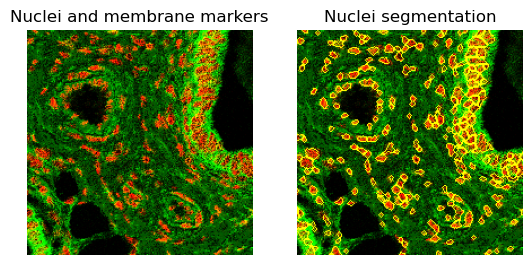

In [12]:
# choosing a subsection
vis_range = {
'h0': 300,
'h1': 500,
'w0': 200,
'w1': 400
}

#TODO: change accordingly based on membrane info
vis_channels_RGB = ['nuclei','membrane']

# visualize raw membrane and nuclei here
pseudoRGB, quantiles, color_pool = cytof_img.visualize_channels(channel_names=vis_channels_RGB, visualize=False)

# visualize nuclei segmentation
marked_image_nuclei = cytof_img.visualize_seg(segtype="nuclei", show=False)

fig, ax = plt.subplots(1,2)
ax[0].imshow(pseudoRGB[vis_range['h0']:vis_range['h1'], vis_range['w0']:vis_range['w1'],:])
ax[1].imshow(marked_image_nuclei[vis_range['h0']:vis_range['h1'], vis_range['w0']:vis_range['w1'],:])

ax[0].set_title('Nuclei and membrane markers')
ax[1].set_title('Nuclei segmentation')

ax[0].axis('off')
ax[1].axis('off')
plt.show()

# used for saving individual figures
# plt.imshow(pseudoRGB[vis_range['h0']:vis_range['h1'], vis_range['w0']:vis_range['w1'],:])
# plt.title('Nuclei and membrane markers')
# plt.axis('off')
# plt.savefig('figure2a.png', dpi=300)

# plt.imshow(marked_image_nuclei[vis_range['h0']:vis_range['h1'], vis_range['w0']:vis_range['w1'],:])
# plt.title('Nuclei segmentation')
# plt.axis('off')
# plt.savefig('figure2b.png', dpi=300)



In [13]:
cytof_img.channels

['ArgonDimers-Ar80',
 'RutheniumTetroxide-Ru96',
 'RutheniumTetroxide-Ru98',
 'RutheniumTetroxide-Ru99',
 'RutheniumTetroxide-Ru100',
 'RutheniumTetroxide-Ru101',
 'RutheniumTetroxide-Ru102',
 'RutheniumTetroxide-Ru104',
 'Histone H3-In113',
 'Histone H3-La139',
 'Cytokeratin 5-Pr141',
 'Fibronectin-Nd142',
 'Cytokeratin 19-Nd143',
 'Cytokeratin 8or18-Nd144',
 'Twist-Nd145',
 'CD68-Nd146',
 'Keratin 14 (KRT14)-Sm147',
 'SMA-Nd148',
 'Vimentin-Sm149',
 'c-Myc-Nd150',
 'c-erbB-2 - Her2-Eu151',
 'CD3-Sm152',
 'Histone H3-Eu153',
 'Erk1or2-Sm154',
 'Slug-Gd155',
 'Rabbit IgG H L-Gd156',
 'Progesterone Receptor AorB-Gd158',
 'p53-Tb159',
 'CD44-Gd160',
 'EpCAM-Dy161',
 'CD45-Dy162',
 'GATA3-Dy163',
 'CD20-Dy164',
 'b-Catenin-Ho165',
 'Carbonic Anhydrase IX-Er166',
 'undefined-Er167',
 'Ki-67-Er168',
 'EGFR-Tm169',
 'S6-Er170',
 'Sox9-Yb171',
 'vWF-CD31-Yb172',
 'mTOR-Yb173',
 'Cytokeratin 7-Yb174',
 'pan Cytokeratin-Keratin Epithelial-Lu175',
 'cleaved PARP-Cleaved Caspase3-Yb176',
 'nuclei

## Figure 2C
Compare segmentation results

In [ ]:
# set color map to prettify
cmap_set3 = plt.get_cmap("Set3")
cmap_tab20c = plt.get_cmap("tab20c")
colors = [cmap_tab20c.colors[_] for _ in range(len(cmap_tab20c.colors))] + \
    [cmap_set3.colors[_] for _ in range(len(cmap_set3.colors))]


In [ ]:
CP_TITAN_PATH = '/project/DPDS/Xiao_lab/shared/deep_learning_SW_RR/cytof/image_cytof/notebooks/developer'
IMC_FOLDER = '/archive/DPDS/Xiao_lab/shared/shidan/hyperion/The Single-Cell Pathology Landscape of Breast Cancer/OMEandSingleCellMasks/OMEnMasks/ome/ome'
IMC_MASKS_FOLDER = '/archive/DPDS/Xiao_lab/shared/shidan/hyperion/The Single-Cell Pathology Landscape of Breast Cancer/OMEandSingleCellMasks/OMEnMasks/Basel_Zuri_masks/Basel_Zuri_masks'
CP_MASK_PATH = '/project/DPDS/Xiao_lab/shared/deep_learning_SW_RR/cytof/image_cytof/notebooks/developer/roi_masks/cellprofiler/'
TITAN_MASK_PATH = '/project/DPDS/Xiao_lab/shared/deep_learning_SW_RR/cytof/image_cytof/notebooks/developer/roi_masks/titan/nrrd_keep'

imc_file = 'BaselTMA_SP43_25.8kx22ky_10500x6500_8_20170928_114_115_X4Y8_262_a0_full.tiff'

# find CellProfiler and TITAN results
# load the roi -> imc mapping file
roi_name_dict = json.load(open(os.path.join(CP_TITAN_PATH, 'roi_num_imc_name_map.json')))

roi_num = list(roi_name_dict.values()).index(imc_file)

# check the filenames match
assert roi_name_dict[f'rois/roi{roi_num}'] == imc_file

# load the CP masks result
cell_seg_cellprofiler = skimage.io.imread(os.path.join(CP_MASK_PATH, f'roi{roi_num}_cell_masks.tiff'), plugin="tifffile")

# load the TITAN masks result
cell_seg_titan, _ = nrrd.read(os.path.join(TITAN_MASK_PATH, f'roi{roi_num} Cell Mask.nrrd'))
cell_seg_titan = np.transpose(cell_seg_titan, axes=(1,0,2))[:,:,0] # TITAN processing always transposes the original images

# load ground truth
cell_seg_gt = skimage.io.imread(os.path.join(IMC_MASKS_FOLDER, imc_file.split('.tiff')[0]+"_maks.tiff"), plugin='tifffile')
  
cell_seg_pred = cell_seg - 1 # to match with gt label

# label the segmentation with better color
cell_seg_gt = label2rgb(cell_seg_gt, bg_label=0, colors=colors)
cell_seg_pred = label2rgb(cell_seg_pred, bg_label=0, colors=colors)
cell_seg_cellprofiler = label2rgb(cell_seg_cellprofiler, bg_label=0, colors=colors)
cell_seg_titan = label2rgb(cell_seg_titan, bg_label=0, colors=colors)



In [ ]:

# visualize the results with ground truth
fig, axs = plt.subplots(1,4, figsize=(18,6))
axs[0].imshow(cell_seg_gt[vis_range['h0']:vis_range['h1'], vis_range['w0']:vis_range['w1']])
axs[0].set_title("Ground Truth")

axs[1].imshow(cell_seg_pred[vis_range['h0']:vis_range['h1'], vis_range['w0']:vis_range['w1']])
axs[1].set_title("MultiTAP")

axs[2].imshow(cell_seg_cellprofiler[vis_range['h0']:vis_range['h1'], vis_range['w0']:vis_range['w1']])
axs[2].set_title("CellProfiler")

axs[3].imshow(cell_seg_titan[vis_range['h0']:vis_range['h1'], vis_range['w0']:vis_range['w1']])
axs[3].set_title("TITAN")

# turn off axis
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
axs[3].axis('off')

# plt.savefig('perform_comp.png', dpi=300)

## Figure 2D
To generate the `performance.json` file, please refer to `supplemental/eval_cellprofiler_titan.py`

In [ ]:
perform_dict = json.load(open('preprocessed/final_basel_performance.json'))
perform_df = pd.DataFrame()

# threshold vs. f-score graph
perform_df['IoU Threshold'] = np.arange(0.01,1, step=0.01)
for res_key in perform_dict.keys():
    fscore_list = perform_dict[res_key][3]

    # if no matching values, they have metric_val=0
    num_zeros_to_pad = 99 - len(fscore_list)
    fscore_list = np.pad(fscore_list, pad_width=(0,num_zeros_to_pad), constant_values=0)
    perform_df[res_key] = fscore_list

# transpose the performance df for plotting
perform_df_long = pd.melt(perform_df, id_vars=['IoU Threshold'], var_name="Method", value_name="F1 score")

# make the plot
sns.lineplot(perform_df_long, x='IoU Threshold', y='F1 score', hue='Method', linewidth=5, palette=sns.color_palette("Set2", 3))    

# Get the current legend
legend = plt.legend()

# Set the linewidth of the legend lines
for line in legend.get_lines():
    line.set_linewidth(5)  # Adjust the linewidth as needed

# plt.xlim([0,1])
# plt.ylim([0,1])
# plt.savefig('seg-fscore.png', dpi=300)
plt.show()

## Figure 2E

In [ ]:
params = SetParameters(
    # IMC file
    # filename='/archive/DPDS/Xiao_lab/shared/shidan/hyperion/The Single-Cell Pathology Landscape of Breast Cancer/OMEandSingleCellMasks/OMEnMasks/ome/ome/BaselTMA_SP43_25.8kx22ky_10500x6500_8_20170928_114_115_X4Y8_262_a0_full.tiff',
    
    # Opal file
    filename=os.path.join(ROOT_DIR, 'example_data/TP00899-T0-S1-1_Scan1_reg_x5000_y8000.tiff'),
    outdir="../test_out/tiffs/single_roi", 
    slide="0",
    roi="1",
    label_marker_file = "supplemental/markers_labels_phenochart.txt",
)

In [ ]:
# read slide into class object
cytof_img_opal, _ = cytof_read_data_roi(params.filename, slide=params.slide, roi=params.roi)

# set the channels and markers
labels_markers = yaml.load(open(params.label_marker_file, "rb"), Loader=yaml.Loader)
cytof_img_opal.set_markers(**labels_markers)

print(cytof_img_opal.channels)

In [ ]:
#TODO: change accordingly
channel_dict = {
        'nuclei': ['DAPI-DNA'],
    }

setattr(params, 'channel_dict', channel_dict)

# define special channels (if desired)
channels_rm = cytof_img_opal.define_special_channels(params.channel_dict, rm_key='nuclei')


In [ ]:
#TODO: change accordingly based on membrane info
vis_channels_RGB = ['nuclei']

# visualize raw nuclei here
pseudoRGB, quantiles, color_pool = cytof_img_opal.visualize_channels(channel_names=vis_channels_RGB, visualize=False)

# No marker designed to stain membrane in this Opal batch
nuclei_seg, cell_seg = cytof_img_opal.get_seg(use_membrane=False, 
                                         radius=params.cell_radius,
                                         show_process=False)
cell_seg_pred = cell_seg - 1 # to match with gt label

# label the segmentation with better color
cell_seg_pred = label2rgb(cell_seg_pred, bg_label=0, colors=colors)
                                   

In [ ]:
%matplotlib inline


# visualize the results with ground truth
fig, axs = plt.subplots(1,2, figsize=(18,6))
axs[0].imshow(pseudoRGB[:,:,0], cmap='gray')
axs[0].set_title("Nuclei markers")
axs[0].axis('off')

axs[1].imshow(cell_seg_pred)
axs[1].set_title("MultiTAP cell segmentation")
axs[1].axis('off')

# plt.savefig('figure2e.png', dpi=300)  


# Figure 3

The following step takes about 10 minutes to finish for a 150MB IMC file.

In [ ]:
# helper func
# help write/read df data types into npz
def save_df_npz(df, filename):
    arrays = {col: df[col].to_numpy() for col in df.columns}
    np.savez(filename, **arrays, columns=df.columns.to_numpy(), index=df.index.to_numpy())

def load_df_npz(filename):
    data = np.load(filename, allow_pickle=True)
    cols = data["columns"]
    idx = data["index"]
    arrays = {col: data[col] for col in cols}
    return pd.DataFrame(arrays, index=idx)


In [ ]:
# read in preprocessed feature extraction data for tutorial efficiency
# e.q. to self.features
json_file = open('./preprocessed/BrCa_114_115_X4Y8_features.json', 'r')
brca_feats_names = json.load(json_file)
print(brca_feats_names.keys())

# read in df_feature
# e.q. to self.df_feature
brca_df_feature = load_df_npz('./preprocessed/ROI_114_115_X4Y8_262.npz')
setattr(cytof_img, 'df_feature', brca_df_feature)
setattr(cytof_img, 'features', brca_feats_names)


# # actually extract the features (if not preprocessed)
# # takes about 10min for 114_115_X4Y8_262
# cytof_img.extract_features(filename=cytof_img.filename)
# # save_df_npz(cytof_img.df_feature.copy(), './preprocessed/ROI_114_115_X4Y8_262.npz')

In [ ]:
# normalize the extracted features
cytof_img.feature_quantile_normalization(qs=[75], vis_compare=False) 

# treat as a cohort (for upcoming analyses)
dict_cytof_img = {f"{cytof_img.slide}_{cytof_img.roi}": cytof_img}
# cytof_img.calculate_quantiles(qs=[75])
cytof_cohort = CytofCohort(cytof_images=dict_cytof_img)
cytof_cohort.batch_process_feature()

In [ ]:
# runs marker positive summary for all images in the cohort
cytof_cohort.generate_summary(feat_type="normed_scaled", normq=75, verbose=False, vis_thres=False)

## Figure 3A, B

In [ ]:
VIZ_CHANNEL = 'pan Cytokeratin-Keratin Epithelial-Lu175'

stain_nuclei, stain_cell, color_dict = cytof_img.visualize_marker_positive(
                                        marker=VIZ_CHANNEL,
                                        feature_type="scaled",
                                        accumul_type="sum",
                                        normq=75,
                                        show_boundary=True,
                                        color_list=[(0,0,1), (0,1,0)], # negative, positive
                                        color_bound=(0,0,0),
                                        show_colortable=False)

vis_channel_names = [VIZ_CHANNEL, "nuclei"]
pseudoRGB, quantiles, color_pool = cytof_img.visualize_channels(channel_names=vis_channel_names, 
                              visualize=False)

In [ ]:
%matplotlib inline

r, c, _ = pseudoRGB.shape

vis_range = {
'h0': 0,
'h1': r,
'w0': 0,
'w1': c
}

CHANNEL_PRINT = 'pan-CK'
plt.figure(figsize=(10, 10))
plt.imshow(pseudoRGB)
plt.title(f'Nuclei and {CHANNEL_PRINT}', fontsize=20)
# plt.savefig(os.path.join(BASE_FIG_DIR, 'figure3a.pdf'), format='pdf', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 10))
plt.imshow(stain_cell[vis_range['h0']:vis_range['h1'], vis_range['w0']:vis_range['w1']])
plt.title(F'Positive {CHANNEL_PRINT} cells', fontsize=20)
# plt.savefig(os.path.join(BASE_FIG_DIR, 'figure3b.pdf'), format='pdf', dpi=300, bbox_inches='tight')
plt.show()



## Figure 3ab transition

In [ ]:
from sklearn.mixture import GaussianMixture
import scipy

# modified from utils._get_thresholds
# used specifically for visualizing a marker
def _get_thresholds(df_feature: pd.DataFrame,
                    features: List[str],
                    thres_bg: float = 0.3,
                    visualize: bool = True,
                    verbose: bool = False,
                    viz_title: str = ''):
    """Calculate thresholds for each feature by assuming a Gaussian Mixture Model
    Inputs:
        df_feature = dataframe of extracted feature summary
        features   = a list of features to calculate thresholds from
        thres_bg   = a threshold such that the component with the mixing weight greater than the threshold would
                            be considered as background. (Default=0.3)
        visualize  = a flag indicating whether to visualize the feature distributions and thresholds or not.
                            (Default=True)
        verbose    = a flag indicating whether to print calculated values on screen or not. (Default=False)
    Outputs:
        thresholds = a dictionary of calculated threshold values
    :param df_feature: pandas.core.frame.DataFrame
    :param features: list
    :param visualize: bool
    :param verbose: bool
    :return thresholds: dict
    """
    thresholds = {}
    for f, feat_name in enumerate(features):
        X = df_feature[feat_name].values.reshape(-1, 1)
        gm = GaussianMixture(n_components=2, random_state=0, n_init=2).fit(X)
        mu = np.min(gm.means_[gm.weights_ > thres_bg])
        which_component = np.argmax(gm.means_ == mu)

        if verbose:
            print(f"GMM mean values: {gm.means_}")
            print(f"GMM weights: {gm.weights_}")
            print(f"GMM covariances: {gm.covariances_}")

        X     = df_feature[feat_name].values
        hist  = np.histogram(X, 150)
        sigma = np.sqrt(gm.covariances_[which_component, 0, 0])
        background_ratio = gm.weights_[which_component]
        thres = sigma * 2.5 + mu
        thresholds[feat_name] = thres

        n = sum(X > thres)
        percentage = n / len(X)

        ## visualize
        if visualize:
            fig, ax = plt.subplots(1, 1)
            ax.hist(X, 150, density=True)
            ax.set_xlabel("log2-normalized expression")
            ax.set_ylabel("Density")
            ax.plot(hist[1], scipy.stats.norm.pdf(hist[1], mu, sigma) * background_ratio, c='red')

            _which_component = np.argmin(gm.means_ == mu)
            _mu = gm.means_[_which_component]
            _sigma = np.sqrt(gm.covariances_[_which_component, 0, 0])
            ax.plot(hist[1], scipy.stats.norm.pdf(hist[1], _mu, _sigma) * (1 - background_ratio), c='orange')

            ax.axvline(x=thres, c='red')
            ax.text(0.25, 0.7, "n={}, percentage={}".format(n, np.round(percentage, 3)), ha='center', va='center',
                    transform=ax.transAxes)
            ax.text(0.25, 0.9, "mu={}, sigma={}".format(np.round(mu, 2), np.round(sigma, 2)), ha='center', va='center',
                    transform=ax.transAxes)
            ax.text(0.25, 0.8, "background ratio={}".format(np.round(background_ratio, 2)), ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_title(viz_title)
            plt.savefig(os.path.join(BASE_FIG_DIR, 'figure3ab.pdf'), format='pdf', dpi=300)
            plt.show()
    return thresholds

In [ ]:
# extracts the df_feature
df_feature_name = 'df_feature_75normed_scaled'
df_feat = getattr(cytof_cohort, df_feature_name)

In [ ]:
pos_viz_marker_name = VIZ_CHANNEL
viz_feature = f'{pos_viz_marker_name}_cell_sum'
_get_thresholds(df_feat, features=[viz_feature], viz_title='')


## Figure 3C, D

In [ ]:
# perform phenograph clustering
key_pheno = cytof_cohort.clustering_phenograph()


In [ ]:
## visualize from preprocess
df_feats, commus, cluster_protein_exps, figs, figs_scatter, figs_exps = cytof_cohort.vis_phenograph(
    key_pheno=key_pheno,
    level="cohort",
    save_vis=False, # change here to save
    show_plots=True,
    plot_together=False,
    scatter_dot_size=3)


In [ ]:
figs_cluster, ax_scatter = figs_scatter['cohort']
ax_scatter.set_title('')
ax_scatter.set_xlabel('UMAP1')
ax_scatter.set_ylabel('UMAP2')

figs_cluster.set_size_inches(7, 5)
figs_cluster.tight_layout()
# figs_cluster.savefig(os.path.join(BASE_FIG_DIR, 'figure3c.pdf'), dpi=300, format='pdf', bbox_inches='tight')

figs_cluster

In [ ]:
%matplotlib inline
fig_cluster_exp, ax_exp = figs_exps['cohort']['cell_sum']
ax_exp.set_xticklabels(ax_exp.get_xticklabels(), rotation=45, ha="right")
ax_exp.set_title('Mean expression')
fig_cluster_exp.set_size_inches(10, 5)
fig_cluster_exp.tight_layout()
# fig_cluster_exp.canvas.draw()
# fig_cluster_exp.savefig(os.path.join(BASE_FIG_DIR, 'figure3d.pdf'), dpi=300, format='pdf', bbox_inches='tight')
fig_cluster_exp

## Figure 3E

In [ ]:
# attch PhenoGraph results to individual ROIs
cytof_cohort.attach_individual_roi_pheno(key_pheno, override=True)

# PhenoGraph clustering visualization
pheno_stain_nuclei, pheno_stain_cell, color_dict = cytof_img.visualize_pheno(key_pheno=key_pheno)


In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(pheno_stain_cell[vis_range['h0']:vis_range['h1'], vis_range['w0']:vis_range['w1'],:])
# plt.savefig(os.path.join(BASE_FIG_DIR, 'figure3e.pdf'), format='pdf', dpi=300, bbox_inches='tight')


# Figure 4
Generate ROI and slide level interaction analysis.

Cohort was processed externally. Too large to be computed by IPython kernels. See `CLIscripts/batch_feature_extract.sh`

In [ ]:
one_slide = 'BaselTMA_SP43_25'
one_roi = '114_115_X4Y8_262'

## Figure 4A

### loading the img from pkl file
pkl file generated from `CLIscripts.batch_process_feature.py`

In [ ]:
# calling the individual ROI co-expression-analysis
df_co_pos_prob, df_expected_prob = cytof_img.roi_co_expression(feature_name='75normed_scaled', accumul_type='sum', return_components=False)

epsilon = 1e-6 # avoid divide by 0 or log(0)

# Normalize and fix Nan
edge_percentage_norm = np.log10(df_co_pos_prob.values / (df_expected_prob.values+epsilon) + epsilon)

# if observed/expected = 0, then log odds ratio will have log10(epsilon)
# no observed means co-expression cannot be determined, does not mean strong negative co-expression
edge_percentage_norm[edge_percentage_norm == np.log10(epsilon)] = 0

# do some post processing
marker_all_clean = [m.replace('_cell_sum', '') for m in df_expected_prob.columns]


# fig = plt.figure()
clustergrid = sns.clustermap(edge_percentage_norm,
                # clustergrid = sns.clustermap(edge_percentage_norm,
                center=np.log10(1 + epsilon), cmap='RdBu_r', vmin=-1, vmax=3,
                xticklabels=marker_all_clean, yticklabels=marker_all_clean)

plt.title(f'{one_slide} ROI:{one_roi}')
# plt.savefig('figure4a.pdf', format='pdf', dpi=300, bbox_inches='tight') # tight to save all edges of the figure
plt.show()

## Figure 4B
Co-expression analysis at the slide level. Because the large number of ROIs in each slide, Jupyter Notebooks did not allow sufficient OPENBLAS threads. Please reference `supplemental/cohort_coexpression.py` on how to generate figure 4b.

# Figure 5
Spatial interactions

In [ ]:
df_expected_prob, df_cell_interaction_prob = cytof_img.roi_interaction_graphs(feature_name='75normed_scaled', accumul_type='sum', method='k-neighbor', threshold=30)

# do some post processing
marker_all = df_expected_prob.columns
epsilon = 1e-6

# Normalize and fix Nan
edge_percentage_norm = np.log10(df_cell_interaction_prob.values / (df_expected_prob.values+epsilon) + epsilon)

# if observed/expected = 0, then log odds ratio will have log10(epsilon)
# no observed means interaction cannot be determined, does not mean strong negative interaction
edge_percentage_norm[edge_percentage_norm == np.log10(epsilon)] = 0


In [ ]:
marker_all_clean = [m.replace('_cell_sum', '') for m in marker_all]
print(marker_all_clean[:5])
print(np.min(edge_percentage_norm))
print(np.max(edge_percentage_norm))

In [ ]:
# visualize the coexpression plot
%matplotlib inline
clustergrid = sns.clustermap(edge_percentage_norm,
                            # clustergrid = sns.clustermap(edge_percentage_norm,
                            center=np.log10(1 + epsilon), cmap='bwr', vmin=-2, vmax=2,
                            xticklabels=marker_all_clean, yticklabels=marker_all_clean)

plt.title(f'{one_slide} ROI:{one_roi}')

# plt.savefig(os.path.join(BASE_FIG_DIR, 'figure5a.pdf'), format='pdf', dpi=300, bbox_inches='tight') # tight to save all edges of the figure
plt.show()

In [ ]:
# visualize the coexpression plot
%matplotlib inline
clustergrid = sns.clustermap(edge_percentage_norm,
                            # clustergrid = sns.clustermap(edge_percentage_norm,
                            center=np.log10(1 + epsilon), cmap='bwr', vmin=-2, vmax=2,
                            xticklabels=marker_all_clean, yticklabels=marker_all_clean)

plt.title(f'{one_slide} ROI:{one_roi}')

# plt.savefig('figure5a.pdf', format='pdf', dpi=300, bbox_inches='tight') # tight to save all edges of the figure
plt.show()

### Marker visualization check

In [ ]:
def visualize_marker(cytof_img, channel1, channel2):
  """
  Visualizes marker given the marker and channel name. This is visualizaed along with the nuclei channel

  """
  vis_channel_names = [channel1, "nuclei"]
  pseudoRGB1, quantiles, color_pool = cytof_img.visualize_channels(channel_names=vis_channel_names, 
                              visualize=False)

  vis_channel_names = [channel2, "nuclei"]
  pseudoRGB2, quantiles, color_pool = cytof_img.visualize_channels(channel_names=vis_channel_names, 
                              visualize=False)

  fig, axs = plt.subplots(1,2,figsize=(15, 5))

  axs[0].imshow(pseudoRGB1), axs[0].set_title(channel1)
  axs[1].imshow(pseudoRGB2), axs[1].set_title(channel2)
  plt.show()

  

In [ ]:
def viz_pos_marker_pair(cytof_img, marker1, marker2, vis_range, set_title=True):
  
  stain_nuclei1, stain_cell1, color_dict = cytof_img.visualize_marker_positive(
                                        marker=marker1,
                                        feature_type="scaled",
                                        accumul_type="sum",
                                        normq=75,
                                        show_boundary=True,
                                        color_list=[(0,0,1), (0,1,0)], # negative, positive
                                        color_bound=(0,0,0),
                                        show_colortable=False)

  stain_nuclei2, stain_cell2, color_dict = cytof_img.visualize_marker_positive(
                                        marker=marker2,
                                        feature_type="scaled",
                                        accumul_type="sum",
                                        normq=75,
                                        show_boundary=True,
                                        color_list=[(0,0,1), (0,1,0)], # negative, positive
                                        color_bound=(0,0,0),
                                        show_colortable=False)
  fig, axs = plt.subplots(1,2)

  axs[0].imshow(stain_cell1[vis_range['h0']:vis_range['h1'], vis_range['w0']:vis_range['w1']])
  axs[1].imshow(stain_cell2[vis_range['h0']:vis_range['h1'], vis_range['w0']:vis_range['w1']])
  
  if set_title: # not for saving subplots
    axs[0].set_title(f'positive {marker1} cells')
    axs[1].set_title(f'positive {marker2} cells')
    plt.tight_layout()
  else: # don't apply tight layout
    axs[0].axis('off')
    axs[1].axis('off')


In [ ]:
%matplotlib inline
vis_range = {
'h0': 000,
'h1': 800,
'w0': 000,
'w1': 900
}


viz_pos_marker_pair(cytof_img, 'EpCAM-Dy161', 'Histone H3-La139', vis_range)
# plt.savefig('figure5b.pdf', format='pdf', dpi=300)

In [ ]:
%matplotlib inline
vis_range = {
'h0': 350,
'h1': 600,
'w0': 0,
'w1': 250
}


viz_pos_marker_pair(cytof_img, 'EpCAM-Dy161', 'Histone H3-La139', vis_range, set_title=False)
# plt.axis('off')

# plt.savefig('figure5b-1.pdf', format='pdf', dpi=300)

In [ ]:
%matplotlib inline 
vis_range = {
  'h0': 000,
  'h1': 800,
  'w0': 000,
  'w1': 900
  }

viz_pos_marker_pair(cytof_img, 'CD44-Gd160', 'Cytokeratin 19-Nd143', vis_range)
# plt.savefig('figure5c.pdf', format='pdf', dpi=300)

In [ ]:
%matplotlib inline 
vis_range = {
  'h0': 230,
  'h1': 480,
  'w0': 180,
  'w1': 430
  }

viz_pos_marker_pair(cytof_img, 'CD44-Gd160', 'Cytokeratin 19-Nd143', vis_range, set_title=False)
# plt.savefig('figure5c-1.pdf', format='pdf', dpi=300)

# Figure 6

In [3]:
from statsmodels.stats.multitest import multipletests
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines import KaplanMeierFitter

def flatten_interaction_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """
    Flattens a non-symmetric spatial interaction matrix into a single-row
    wide-format DataFrame. Each column is a directional pair (e.g., 'GeneA_to_GeneB').

    Parameters:
        df (pd.DataFrame): A square DataFrame of spatial interaction values.

    Returns:
        pd.DataFrame: A single-row wide-format DataFrame with directional interaction pairs.
    """
    if df.shape[0] != df.shape[1]:
        raise ValueError("Input DataFrame must be square.")
    if not df.columns.equals(df.index):
        raise ValueError("DataFrame must have matching row and column labels.")

    colnames = [f"{row}_to_{col}" for row in df.index for col in df.columns]
    values = df.values.flatten()

    return pd.DataFrame([values], columns=colnames)

def extract_roi_id(roi_id):
    try:

        # first split by _
        split = roi_id.split('_')
        # special case for 178 A and C
        if roi_id.startswith('178_A') or roi_id.startswith('178_C'):
            return f"{split[0]}_{split[2]}{split[3]},{split[4]}"
        elif roi_id.startswith('178_B'): # special case for 178 B
            return f"{split[0]}_{split[3]}{split[4]},{split[5]}"
        else: # all other cases
            return f"{split[0]}_{split[2]},{split[3]}"
    except IndexError:
        return None  # or raise an error / return roi_id unchanged

cell_type_cols = ['final_cell_type_B cells', 'final_cell_type_CD4',
       'final_cell_type_CD4 Treg', 'final_cell_type_CD8',
       'final_cell_type_Collagen CAF', 'final_cell_type_IDO_CD4',
       'final_cell_type_IDO_CD8', 'final_cell_type_IFN CAF',
       'final_cell_type_Ki67_CD4', 'final_cell_type_Ki67_CD8',
       'final_cell_type_PD1 CD4', 'final_cell_type_PDPN CAF',
       'final_cell_type_SMA CAF', 'final_cell_type_TCF1/7 CD4',
       'final_cell_type_TCF1/7 CD8', 'final_cell_type_dCAF',
       'final_cell_type_endothelial',
       'final_cell_type_high endothelial venules (HEV)',
       'final_cell_type_hypoxic CAF', 'final_cell_type_hypoxic tCAF',
       'final_cell_type_iCAF', 'final_cell_type_lymphatic endothelial',
       'final_cell_type_mCAF', 'final_cell_type_myeloid',
       'final_cell_type_neutrophils', 'final_cell_type_tCAF',
       'final_cell_type_vCAF']

## Figure 6A
Figure 6A is the antibody compositions of vessel cells and CAFs. See manuscript for details.

## Figure 6B

In [4]:
accuml_type = 'sum'

# read in preprocessed spatial interaction by cell type for each pt
# spatial_pt_df = pd.read_csv(f"./preprocessed/nontumor_spatial_kneighbor15_{accuml_type}.csv", index_col=0)
spatial_pt_df = pd.read_csv("/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/nontumor_spatial_kneighbor15_sum.csv", index_col=0)

n_roi = len(set(spatial_pt_df['roi_id']))
print(f"{n_roi} rois identified")

# set index as col
spatial_pt_df = spatial_pt_df.reset_index(names='cell_type')

# 0 was used to indicate not observed, but average over will skew the df
spatial_pt_df = spatial_pt_df.replace(0, np.nan)
spatial_pt_df

1950 rois identified


,cell_type,final_cell_type_B cells,final_cell_type_CD4,final_cell_type_CD4 Treg,final_cell_type_CD8,final_cell_type_Collagen CAF,final_cell_type_IDO_CD4,final_cell_type_IDO_CD8,final_cell_type_IFN CAF,final_cell_type_Ki67_CD4,...,final_cell_type_hypoxic CAF,final_cell_type_hypoxic tCAF,final_cell_type_iCAF,final_cell_type_lymphatic endothelial,final_cell_type_mCAF,final_cell_type_myeloid,final_cell_type_neutrophils,final_cell_type_tCAF,final_cell_type_vCAF,roi_id
0,final_cell_type_B cells,0.130844,NaN,NaN,NaN,NaN,NaN,NaN,-0.018393,NaN,...,-0.640915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_175_A_A1_1
1,final_cell_type_CD4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_175_A_A1_1
2,final_cell_type_CD4 Treg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_175_A_A1_1
3,final_cell_type_CD8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_175_A_A1_1
4,final_cell_type_Collagen CAF,NaN,NaN,NaN,NaN,1.060534,NaN,NaN,0.592758,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.450522,0.851875,NaN,NSCLC_ALL_175_A_A1_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52645,final_cell_type_mCAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_88_C_C8_9
52646,final_cell_type_myeloid,-0.260193,NaN,NaN,NaN,-0.291709,NaN,NaN,-0.223930,NaN,...,-0.915807,-0.361197,-0.209109,NaN,NaN,-0.075170,-0.464566,NaN,-0.221077,NSCLC_ALL_88_C_C8_9
52647,final_cell_type_neutrophils,-1.602241,NaN,NaN,NaN,-0.080989,NaN,NaN,NaN,NaN,...,-0.865892,-1.101215,NaN,NaN,NaN,-0.533646,0.285157,NaN,NaN,NSCLC_ALL_88_C_C8_9
52648,final_cell_type_tCAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_88_C_C8_9


In [5]:
# average across patients for each cell type
grouped_spatial = spatial_pt_df.groupby(["cell_type"])[cell_type_cols].mean(numeric_only=False)

# now, fill na with 0 for sns.clustermap() 
grouped_spatial = grouped_spatial.fillna(0)

# positive and negative counts
spatial_vals = grouped_spatial.values
print("# of positive interactions", np.sum(spatial_vals>0))
print("# of negative interactions", np.sum(spatial_vals<0))
print("# of null interactions", np.sum(spatial_vals==0))

# clean up cell type names
clean_spatial_names = [cell_type.replace('final_cell_type_', '') for cell_type in grouped_spatial.columns]

# for better spacing
clean_spatial_names =  [cell_type.replace('high endothelial venules (HEV)', 'HEV') for cell_type in clean_spatial_names]


# of positive interactions 183
# of negative interactions 533
# of null interactions 13


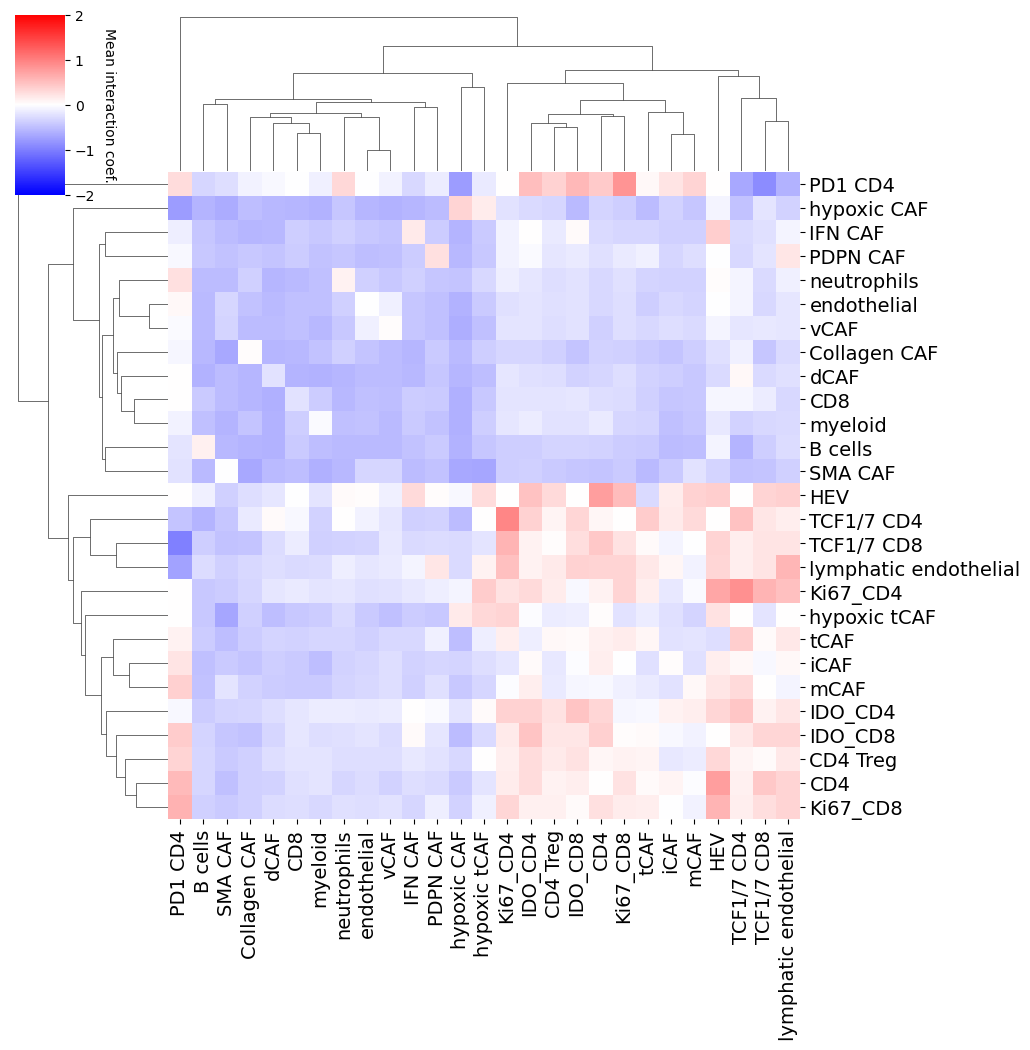

In [6]:

%matplotlib inline
epsilon = 1e-6

clustergrid = sns.clustermap(grouped_spatial,
                            center=np.log10(1 + epsilon), cmap='bwr', vmin=-2, vmax=2,
                            xticklabels=clean_spatial_names, yticklabels=clean_spatial_names)


# Remove y-axis label (index name from pandas DataFrame)
clustergrid.ax_heatmap.set_ylabel("")
clustergrid.ax_heatmap.set_xticklabels(clustergrid.ax_heatmap.get_xmajorticklabels(), fontsize=14)
clustergrid.ax_heatmap.set_yticklabels(clustergrid.ax_heatmap.get_ymajorticklabels(), fontsize=14)
# clustergrid.cax.tick_params(labelsize=22)


# Add label to colorbar
clustergrid.cax.set_ylabel("Mean interaction coef.", rotation=270, labelpad=15)

# plt.savefig(os.path.join(BASE_FIG_DIR, 'figure_7b.pdf'), format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Figure 6C

In [7]:
# flatten out the interaction first
roi_ids = np.unique(spatial_pt_df['roi_id'])
print(f"{len(roi_ids)} ROIs identified")
flat_marker_roi_list = list()

for roi_id in roi_ids:

    try:
        one_spatial_mat = spatial_pt_df[spatial_pt_df['roi_id']==roi_id]

        # setup for flatten
        one_spatial_mat = one_spatial_mat.set_index('cell_type')
        one_spatial_mat = one_spatial_mat.drop(columns='roi_id')

        flat_edge_perc_remapped = flatten_interaction_matrix(one_spatial_mat)
        flat_edge_perc_remapped['ROI_ID'] = roi_id

        flat_marker_roi_list.append(flat_edge_perc_remapped)
    except Exception as e:
        print(f"ROI {roi_id} not processed due to error {e}")


combined_df = pd.concat(flat_marker_roi_list, axis=0, ignore_index=True)



1950 ROIs identified


In [8]:
pt_clinical_data = pd.read_csv('/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/clinical_data_ROI.csv')
print(f"{len(set(pt_clinical_data['Patient_ID']))} unique subjects")
print(np.unique(pt_clinical_data['Patient_ID'], return_counts=True))

# remove controls, no clinical data available for them
pt_clinical_data = pt_clinical_data[pt_clinical_data['Patient_ID']!='Control']
print(f"{len(set(pt_clinical_data['Patient_ID']))} unique subjects")

# # remove unknown and neoadjuvant therapy
pt_clinical_data = pt_clinical_data[~pt_clinical_data['NeoAdj'].isna()]
pt_clinical_data = pt_clinical_data[pt_clinical_data['NeoAdj']!='NeoAdjuvantTherapy'].reset_index(drop=True) # exclude NeoAdjuvantTherapy, see original paper
print(f"{len(set(pt_clinical_data['Patient_ID']))} unique patients")

# keep needed cols only
pt_clinical_data = pt_clinical_data[['RoiID', 'Patient_ID', 'OS', 'DFS', 'Ev.O', 'DX.name']]

# remove duplicates after subsetting for pt and survival info
pt_clinical_data = pt_clinical_data.drop_duplicates(keep='first').reset_index(drop=True)
print(f"{len(set(pt_clinical_data['Patient_ID']))} unique patients")

pt_clinical_data

1071 unique subjects
(array(['175_1', '175_10', '175_100', ..., '88_537', '88_538', 'Control'],
      dtype=object), array([ 2,  2,  2, ...,  2,  2, 91]))
1070 unique subjects
959 unique patients
959 unique patients


,RoiID,Patient_ID,OS,DFS,Ev.O,DX.name
0,"175_A1,1",175_1,254.0,NaN,1.0,Adenocarcinoma
1,"175_A1,2",175_5,3420.0,3420.0,1.0,Adeno squamous cell carcinoma
2,"175_A1,3",175_9,1312.0,1312.0,1.0,Adenocarcinoma
3,"175_A1,4",175_13,1950.0,1950.0,1.0,Adenocarcinoma
4,"175_A1,6",175_21,820.0,820.0,1.0,Adenocarcinoma
...,...,...,...,...,...,...
1785,"88_C8,9",88_521,596.0,370.0,1.0,Squamous cell carcinoma
1786,"88_C8,10",88_525,323.0,323.0,1.0,Adenocarcinoma
1787,"88_C8,11",88_529,1707.0,1707.0,0.0,Squamous cell carcinoma
1788,"88_C8,12",88_533,1652.0,1652.0,0.0,Adenocarcinoma


In [9]:
# first strip the NSCLC_ALL, then map the ROI ID to clinical file format
combined_df['roi_mappable'] = combined_df['ROI_ID'].str.replace('NSCLC_ALL_', '').apply(extract_roi_id)
spatial_clinical_merged = combined_df.merge(pt_clinical_data, how='inner', left_on='roi_mappable', right_on='RoiID')
print("number of unique patients:", spatial_clinical_merged['Patient_ID'].nunique())

# # exclude pt where OS, outcome is unavailable
spatial_clinical_merged = spatial_clinical_merged[~spatial_clinical_merged['OS'].isna()].reset_index(drop=True)
spatial_clinical_merged = spatial_clinical_merged[~spatial_clinical_merged['Ev.O'].isna()].reset_index(drop=True)
print("number of unique patients:", spatial_clinical_merged['Patient_ID'].nunique())
print("number of unique ROIs:", spatial_clinical_merged['roi_mappable'].nunique())

spatial_clinical_merged

number of unique patients: 956
number of unique patients: 953
number of unique ROIs: 1755


,final_cell_type_B cells_to_final_cell_type_B cells,final_cell_type_B cells_to_final_cell_type_CD4,final_cell_type_B cells_to_final_cell_type_CD4 Treg,final_cell_type_B cells_to_final_cell_type_CD8,final_cell_type_B cells_to_final_cell_type_Collagen CAF,final_cell_type_B cells_to_final_cell_type_IDO_CD4,final_cell_type_B cells_to_final_cell_type_IDO_CD8,final_cell_type_B cells_to_final_cell_type_IFN CAF,final_cell_type_B cells_to_final_cell_type_Ki67_CD4,final_cell_type_B cells_to_final_cell_type_Ki67_CD8,...,final_cell_type_vCAF_to_final_cell_type_tCAF,final_cell_type_vCAF_to_final_cell_type_vCAF,ROI_ID,roi_mappable,RoiID,Patient_ID,OS,DFS,Ev.O,DX.name
0,0.130844,NaN,NaN,NaN,NaN,NaN,NaN,-0.018393,NaN,NaN,...,NaN,NaN,NSCLC_ALL_175_A_A1_1,"175_A1,1","175_A1,1",175_1,254.0,NaN,1.0,Adenocarcinoma
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.064503,0.673285,NSCLC_ALL_175_A_A1_10,"175_A1,10","175_A1,10",175_37,3454.0,3454.0,1.0,Adenocarcinoma
2,NaN,NaN,NaN,NaN,0.163243,NaN,NaN,NaN,NaN,NaN,...,NaN,0.389697,NSCLC_ALL_175_A_A1_11,"175_A1,11","175_A1,11",175_41,290.0,261.0,1.0,Adenocarcinoma
3,-0.224310,NaN,NaN,NaN,-0.394078,NaN,NaN,NaN,NaN,NaN,...,NaN,0.228058,NSCLC_ALL_175_A_A1_12,"175_A1,12","175_A1,12",175_45,1649.0,1649.0,1.0,Squamous cell carcinoma
4,-0.263809,NaN,NaN,-0.443824,NaN,NaN,NaN,NaN,NaN,-0.506835,...,NaN,0.088272,NSCLC_ALL_175_A_A1_13,"175_A1,13","175_A1,13",175_49,273.0,273.0,1.0,Squamous cell carcinoma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1750,NaN,NaN,NaN,1.066596,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.109439,NSCLC_ALL_88_C_C8_2,"88_C8,2","88_C8,2",88_493,338.0,338.0,1.0,Adenocarcinoma
1751,1.204031,NaN,NaN,NaN,NaN,NaN,NaN,-1.465734,NaN,NaN,...,-0.341862,-0.171346,NSCLC_ALL_88_C_C8_3,"88_C8,3","88_C8,3",88_497,1350.0,537.0,1.0,Adenocarcinoma
1752,1.243490,NaN,NaN,NaN,NaN,NaN,NaN,0.552815,NaN,NaN,...,-0.150267,-0.377598,NSCLC_ALL_88_C_C8_4,"88_C8,4","88_C8,4",88_501,1848.0,1848.0,0.0,Squamous cell carcinoma
1753,NaN,NaN,NaN,NaN,-0.522795,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.414905,NSCLC_ALL_88_C_C8_5,"88_C8,5","88_C8,5",88_505,688.0,504.0,1.0,Adenocarcinoma


In [10]:
# get the marker and survival columns
marker_cols = list(spatial_clinical_merged.columns[spatial_clinical_merged.columns.str.contains('final_cell_type')])
keep_cols = marker_cols + ['OS', 'Ev.O', 'Patient_ID', 'DX.name']

# subsetting needed columns only
spatial_clinical_for_survival = spatial_clinical_merged[keep_cols].copy()

# Check that tumor type is consistent across ROIs from the same patient before keeping one value.
tumor_type_conflicts = spatial_clinical_for_survival.groupby('Patient_ID')['DX.name'].nunique(dropna=False)
tumor_type_conflicts = tumor_type_conflicts[tumor_type_conflicts > 1]
print(f"Patients with ROI-level tumor type conflicts: {len(tumor_type_conflicts)}")

# Average ROI-level spatial features per patient while preserving patient-level tumor type.
spatial_clinical_for_survival = spatial_clinical_for_survival.groupby('Patient_ID').agg(
    {**{col: 'mean' for col in marker_cols + ['OS', 'Ev.O']}, 'DX.name': 'first'}
).reset_index()
spatial_clinical_for_survival

Patients with ROI-level tumor type conflicts: 0


,Patient_ID,final_cell_type_B cells_to_final_cell_type_B cells,final_cell_type_B cells_to_final_cell_type_CD4,final_cell_type_B cells_to_final_cell_type_CD4 Treg,final_cell_type_B cells_to_final_cell_type_CD8,final_cell_type_B cells_to_final_cell_type_Collagen CAF,final_cell_type_B cells_to_final_cell_type_IDO_CD4,final_cell_type_B cells_to_final_cell_type_IDO_CD8,final_cell_type_B cells_to_final_cell_type_IFN CAF,final_cell_type_B cells_to_final_cell_type_Ki67_CD4,...,final_cell_type_vCAF_to_final_cell_type_iCAF,final_cell_type_vCAF_to_final_cell_type_lymphatic endothelial,final_cell_type_vCAF_to_final_cell_type_mCAF,final_cell_type_vCAF_to_final_cell_type_myeloid,final_cell_type_vCAF_to_final_cell_type_neutrophils,final_cell_type_vCAF_to_final_cell_type_tCAF,final_cell_type_vCAF_to_final_cell_type_vCAF,OS,Ev.O,DX.name
0,175_1,0.168452,NaN,NaN,NaN,NaN,NaN,NaN,-0.018393,NaN,...,0.368047,NaN,-0.467787,-0.572954,NaN,NaN,-0.494354,254.0,1.0,Adenocarcinoma
1,175_10,0.124939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.442446,NaN,-0.189984,-0.302291,-1.296232,-0.673553,-0.206097,1134.0,1.0,Adenocarcinoma
2,175_100,0.301903,NaN,-0.121964,-0.559178,-0.596081,-0.096762,-0.632213,-0.104330,-0.01922,...,NaN,-0.06198,-0.487861,-0.536280,-0.243848,0.132672,0.019130,490.0,1.0,Squamous cell carcinoma
3,175_101,0.342103,NaN,NaN,NaN,-0.614548,NaN,NaN,-0.794573,NaN,...,-0.213500,NaN,-0.627966,0.076574,NaN,NaN,0.109901,1930.0,1.0,Squamous cell carcinoma
4,175_102,0.251555,NaN,NaN,NaN,NaN,NaN,NaN,-0.617567,NaN,...,-0.604280,NaN,NaN,0.070883,-0.096921,-1.073562,0.201454,794.0,1.0,Squamous cell carcinoma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,88_533,-0.033216,NaN,NaN,NaN,-0.973724,0.578830,NaN,NaN,NaN,...,NaN,0.35046,NaN,-0.245520,-0.123012,NaN,0.260963,1652.0,0.0,Adenocarcinoma
949,88_534,-0.093204,NaN,NaN,-0.344663,-0.550429,NaN,NaN,-0.394401,NaN,...,NaN,NaN,-0.136397,-0.808219,NaN,NaN,-0.440283,368.0,1.0,Squamous cell carcinoma
950,88_535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.610603,NaN,NaN,0.082690,1240.0,1.0,Adenocarcinoma
951,88_536,0.401673,NaN,NaN,NaN,-0.906485,NaN,NaN,NaN,NaN,...,NaN,NaN,-1.015462,-0.410854,-1.187941,-0.591622,-0.084282,201.0,1.0,Adenocarcinoma


In [22]:
# split patients into interaction pair high vs. low using the feature mean
results = []
skipped_features = []

# Pre-specified feature eligibility rule for the primary Figure 6C screen.
minimum_pt_thresh = int(0.1*len(spatial_clinical_for_survival)) # 10% of eligible patients should contain this interaction
minimum_group_size = int(0.3*minimum_pt_thresh) # 30% of minimum pt threshold to ensure balance
minimum_group_events = int(0.3*minimum_group_size) # same balancing with events, derived as 30% of the group

# for each spatial interaction feature
for feature in marker_cols:
    km_cols = [feature, 'OS', 'Ev.O', 'Patient_ID']
    km_df = spatial_clinical_for_survival[km_cols].dropna(subset=[feature, 'OS', 'Ev.O']).copy()
    n_available = km_df.shape[0]

    if n_available < minimum_pt_thresh:
        skipped_features.append({'feature': feature, 'reason': 'n_available', 'n_available': n_available})
        continue

    # stratify by interaction strength within the eligible patients
    mean_exp = km_df[feature].mean()
    km_df['exp_group'] = np.where(km_df[feature] > mean_exp, 'high', 'low')

    low_df = km_df[km_df['exp_group'] == 'low']
    high_df = km_df[km_df['exp_group'] == 'high']
    n_low = low_df.shape[0]
    n_high = high_df.shape[0]
    events_low = low_df['Ev.O'].sum()
    events_high = high_df['Ev.O'].sum()

    if min(n_low, n_high) < minimum_group_size:
        skipped_features.append({
            'feature': feature,
            'reason': 'n_per_group',
            'n_available': n_available,
            'n_low': n_low,
            'n_high': n_high,
        })
        continue

    if min(events_low, events_high) < minimum_group_events:
        skipped_features.append({
            'feature': feature,
            'reason': 'events_per_group',
            'n_available': n_available,
            'n_low': n_low,
            'n_high': n_high,
            'events_low': events_low,
            'events_high': events_high,
        })
        continue

    logrank_res = logrank_test(
        low_df['OS'], high_df['OS'],
        event_observed_A=low_df['Ev.O'],
        event_observed_B=high_df['Ev.O']
    )

    results.append({
        'feature': feature,
        'n_available': n_available,
        'n_low': n_low,
        'n_high': n_high,
        'events_low': events_low,
        'events_high': events_high,
        'mean_feature': mean_exp,
        'pval': logrank_res.p_value,
    })

results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df['pval_adj'] = multipletests(results_df['pval'], method='fdr_bh')[1]

skipped_features_df = pd.DataFrame(skipped_features)
print(f"Features tested: {results_df.shape[0]}")
print(f"Features skipped: {skipped_features_df.shape[0]}")
if not skipped_features_df.empty:
    skipped_reason_counts = skipped_features_df['reason'].value_counts().to_frame('n_features')
    try:
        display(skipped_reason_counts)
    except NameError:
        print(skipped_reason_counts)


Features tested: 347
Features skipped: 382


,n_features
n_available,382


In [23]:
# display the df
if results_df.empty:
    print("No features passed the pre-specified eligibility filters.")
else:
    pvalues = results_df['pval']
    pvals_fdr = results_df['pval_adj']
    try:
        display(results_df.sort_values(by='pval'))
    except NameError:
        print(results_df.sort_values(by='pval'))


,feature,n_available,n_low,n_high,events_low,events_high,mean_feature,pval,pval_adj
125,final_cell_type_PDPN CAF_to_final_cell_type_hy...,230,111,119,96.0,78.0,-0.541260,0.000075,0.025877
204,final_cell_type_hypoxic CAF_to_final_cell_type...,245,120,125,100.0,85.0,-0.515872,0.000496,0.086048
226,final_cell_type_hypoxic tCAF_to_final_cell_typ...,168,85,83,72.0,56.0,-0.284985,0.000840,0.097149
20,final_cell_type_B cells_to_final_cell_type_vCAF,605,317,288,207.0,220.0,-0.551601,0.001222,0.105976
266,final_cell_type_mCAF_to_final_cell_type_iCAF,188,92,96,68.0,52.0,-0.228807,0.002486,0.142682
...,...,...,...,...,...,...,...,...,...
333,final_cell_type_vCAF_to_final_cell_type_Ki67_CD8,174,93,81,62.0,59.0,-0.250852,0.989384,0.996507
186,final_cell_type_endothelial_to_final_cell_type...,228,119,109,81.0,71.0,-0.227811,0.991596,0.996507
111,final_cell_type_Ki67_CD8_to_final_cell_type_en...,220,118,102,82.0,67.0,-0.229116,0.993400,0.996507
317,final_cell_type_tCAF_to_final_cell_type_PDPN CAF,188,100,88,74.0,64.0,-0.103088,0.993636,0.996507


In [24]:
results_df[results_df['feature']=='final_cell_type_mCAF_to_final_cell_type_iCAF']

,feature,n_available,n_low,n_high,events_low,events_high,mean_feature,pval,pval_adj
266,final_cell_type_mCAF_to_final_cell_type_iCAF,188,92,96,68.0,52.0,-0.228807,0.002486,0.142682


Plotting KM curves for: final_cell_type_PDPN CAF_to_final_cell_type_hypoxic CAF


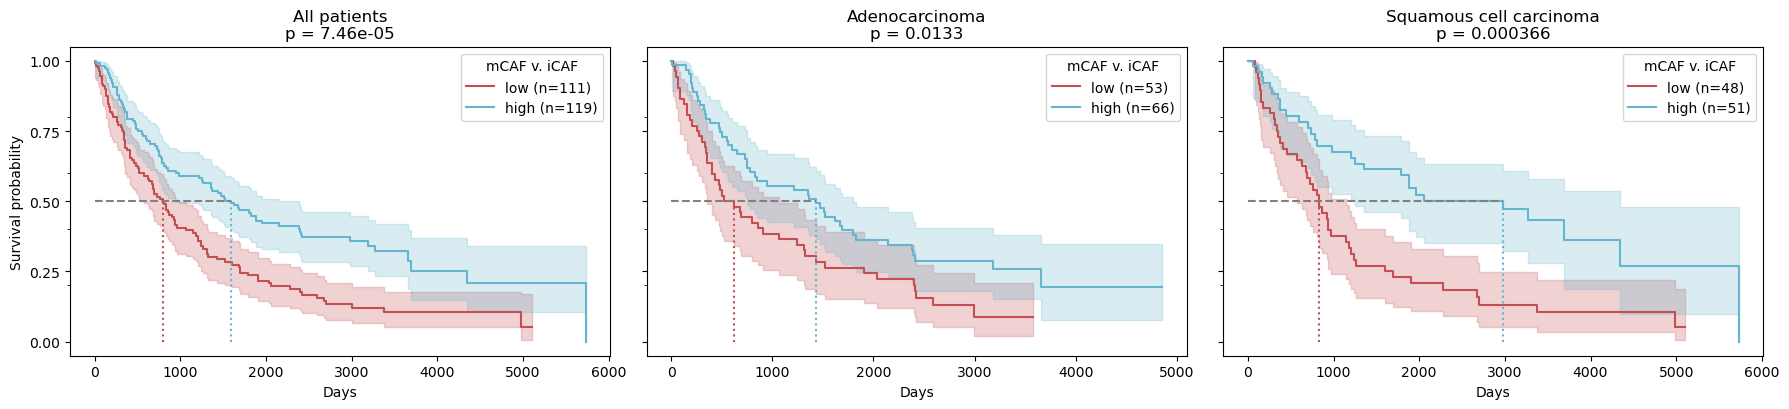

,cohort,tumor_type,feature,n,n_low,n_high,events_low,events_high,mean_feature,pval_logrank,filter_reason
0,All patients,All,final_cell_type_PDPN CAF_to_final_cell_type_hy...,230,111,119,96.0,78.0,-0.541260,0.000075,tested
1,Adenocarcinoma,Adenocarcinoma,final_cell_type_PDPN CAF_to_final_cell_type_hy...,119,53,66,45.0,46.0,-0.442562,0.013270,tested
2,Squamous cell carcinoma,Squamous cell carcinoma,final_cell_type_PDPN CAF_to_final_cell_type_hy...,99,48,51,43.0,29.0,-0.631540,0.000366,tested


In [25]:
default_best_col = "final_cell_type_mCAF_to_final_cell_type_iCAF"
if 'results_df' in globals() and not results_df.empty:
    best_col = results_df.sort_values(by='pval').iloc[0]['feature']
else:
    best_col = default_best_col

print(f"Plotting KM curves for: {best_col}")


def plot_km_by_feature(ax, data, feature, title, tumor_type=None):
    """Plot KM curves with a mean split and return the two-sample log-rank result."""
    km_cols = [feature, 'OS', 'Ev.O', 'Patient_ID', 'DX.name']
    km_df = data[km_cols].copy()
    if tumor_type is not None:
        km_df = km_df[km_df['DX.name'] == tumor_type].copy()
    km_df = km_df.dropna(subset=[feature, 'OS', 'Ev.O']).copy()

    n_available = km_df.shape[0]
    if n_available < minimum_pt_thresh:
        ax.set_title(f"{title}\ninsufficient eligible patients")
        ax.axis('off')
        return {
            'cohort': title,
            'tumor_type': tumor_type if tumor_type is not None else 'All',
            'feature': feature,
            'n': n_available,
            'n_low': np.nan,
            'n_high': np.nan,
            'events_low': np.nan,
            'events_high': np.nan,
            'mean_feature': np.nan,
            'pval_logrank': np.nan,
            'filter_reason': 'n_available',
        }

    mean_exp = km_df[feature].mean()
    km_df['exp_group'] = np.where(km_df[feature] > mean_exp, 'high', 'low')

    low_df = km_df[km_df['exp_group'] == 'low']
    high_df = km_df[km_df['exp_group'] == 'high']
    n_low = low_df.shape[0]
    n_high = high_df.shape[0]
    events_low = low_df['Ev.O'].sum()
    events_high = high_df['Ev.O'].sum()

    if min(n_low, n_high) < minimum_group_size:
        ax.set_title(f"{title}\ninsufficient group size")
        ax.axis('off')
        return {
            'cohort': title,
            'tumor_type': tumor_type if tumor_type is not None else 'All',
            'feature': feature,
            'n': n_available,
            'n_low': n_low,
            'n_high': n_high,
            'events_low': events_low,
            'events_high': events_high,
            'mean_feature': mean_exp,
            'pval_logrank': np.nan,
            'filter_reason': 'n_per_group',
        }

    if min(events_low, events_high) < minimum_group_events:
        ax.set_title(f"{title}\ninsufficient events")
        ax.axis('off')
        return {
            'cohort': title,
            'tumor_type': tumor_type if tumor_type is not None else 'All',
            'feature': feature,
            'n': n_available,
            'n_low': n_low,
            'n_high': n_high,
            'events_low': events_low,
            'events_high': events_high,
            'mean_feature': mean_exp,
            'pval_logrank': np.nan,
            'filter_reason': 'events_per_group',
        }

    kmf = KaplanMeierFitter()
    medians = {}
    colors = {'low': sns.color_palette('deep')[3], 'high': sns.color_palette('deep')[9]}
    for group in ['low', 'high']:
        group_df = km_df[km_df['exp_group'] == group]
        kmf.fit(
            durations=group_df['OS'],
            event_observed=group_df['Ev.O'],
            label=f"{group} (n={group_df.shape[0]})"
        )
        kmf.plot(ax=ax, c=colors[group])
        medians[group] = kmf.median_survival_time_

    logrank_res = logrank_test(
        low_df['OS'], high_df['OS'],
        event_observed_A=low_df['Ev.O'],
        event_observed_B=high_df['Ev.O']
    )
    p_value = logrank_res.p_value

    finite_medians = [m for m in medians.values() if pd.notna(m) and np.isfinite(m)]
    if finite_medians:
        ax.hlines(0.5, xmin=0, xmax=max(finite_medians), ls='--', color='gray')
        for group, median_survival in medians.items():
            if pd.notna(median_survival) and np.isfinite(median_survival):
                ax.vlines(median_survival, ymin=0, ymax=0.5, ls=':', color=colors[group])

    ax.set_title(f"{title}\np = {p_value:.3g}")
    ax.set_xlabel('Days')
    ax.set_ylabel('Survival probability')
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
    ax.legend(title='mCAF v. iCAF')

    return {
        'cohort': title,
        'tumor_type': tumor_type if tumor_type is not None else 'All',
        'feature': feature,
        'n': n_available,
        'n_low': n_low,
        'n_high': n_high,
        'events_low': events_low,
        'events_high': events_high,
        'mean_feature': mean_exp,
        'pval_logrank': p_value,
        'filter_reason': 'tested',
    }

# P-values below are two-sample log-rank tests for high vs. low groups.
# Each subgroup recomputes its mean cutoff and log-rank p-value within that tumor type.
km_cohorts = [
    ('All patients', None),
    ('Adenocarcinoma', 'Adenocarcinoma'),
    ('Squamous cell carcinoma', 'Squamous cell carcinoma'),
]

fig, axes = plt.subplots(1, len(km_cohorts), figsize=(6 * len(km_cohorts), 4.2), sharey=True)
km_results = []
for ax, (title, tumor_type) in zip(axes, km_cohorts):
    km_results.append(plot_km_by_feature(ax, spatial_clinical_for_survival, best_col, title, tumor_type))

plt.tight_layout()
# plt.savefig(os.path.join(BASE_CSV_DIR, 'figure_6c_tumor_type_km.pdf'), format='pdf', dpi=300, bbox_inches='tight')
plt.show()

km_results_df = pd.DataFrame(km_results)
km_results_df

## Figure 6D

Multivariable Cox proportional hazards analysis for the top spatial interaction feature.

Patients with ROI-level clinical covariate conflicts: 0
Patients before dropping missing values: 953
Missing values before Cox model:


,n_missing
OS,0
Ev.O,0
final_cell_type_PDPN CAF_to_final_cell_type_hypoxic CAF,723
Age,10
Gender,10
Stage,10
Smok,0
Chemo,0
Radio,0


Therapy covariate decisions:
Excluding Chemo: missing=0.0%, counts={0.0: 230}
Excluding Radio: missing=0.0%, counts={0.0: 230}
Patients in Cox model after complete-case filtering: 228
Events in Cox model: 174


,variable,coef,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
0,final_cell_type_PDPN CAF_to_final_cell_type_hy...,-0.489800,0.612749,0.440855,0.851667,3.548035e-03
1,Age,0.027902,1.028295,1.010319,1.046590,1.929624e-03
2,Stage_2.0,0.096631,1.101454,0.633891,1.913896,7.317581e-01
3,Stage_3.0,0.579384,1.784938,0.998869,3.189612,5.044843e-02
4,Stage_4.0,0.546955,1.727983,0.934242,3.196093,8.130216e-02
5,Stage_5.0,1.042314,2.835773,1.730350,4.647389,3.541854e-05
6,Stage_6.0,0.503619,1.654699,0.486600,5.626859,4.199667e-01
7,Stage_7.0,2.096486,8.137522,4.051692,16.343606,3.807422e-09
8,Gender_2.0,0.164274,1.178538,0.834304,1.664802,3.512918e-01
9,Smok_1.0,-0.250598,0.778335,0.420581,1.440400,4.248902e-01


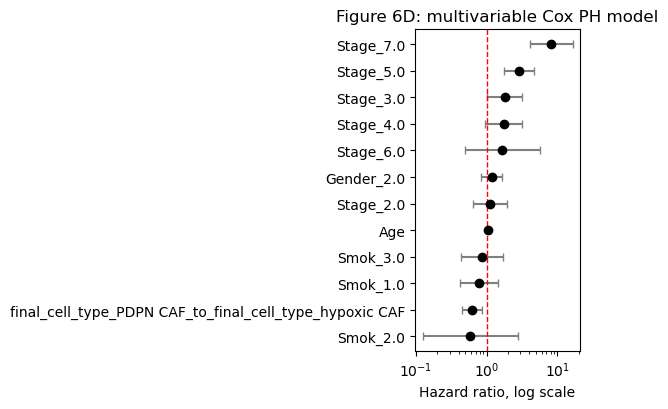

In [26]:
from lifelines import CoxPHFitter

feature_col = str(best_col)
clinical_csv_path = "/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/clinical_data_ROI.csv"

# Re-read the full clinical CSV because pt_clinical_data was narrowed to survival columns above.
cox_clinical_data = pd.read_csv(clinical_csv_path)
cox_clinical_data = cox_clinical_data[cox_clinical_data['Patient_ID'] != 'Control']
cox_clinical_data = cox_clinical_data[~cox_clinical_data['NeoAdj'].isna()]
cox_clinical_data = cox_clinical_data[
    cox_clinical_data['NeoAdj'] != 'NeoAdjuvantTherapy'
].reset_index(drop=True)

clinical_covariates = ['Age', 'Gender', 'Stage', 'Smok', 'Chemo', 'Radio']
cox_clinical_data = cox_clinical_data[['Patient_ID'] + clinical_covariates].drop_duplicates()

# Confirm whether any clinical covariates vary across ROIs for the same patient.
clinical_conflicts = cox_clinical_data.groupby('Patient_ID')[clinical_covariates].nunique(dropna=False)
clinical_conflicts = clinical_conflicts[(clinical_conflicts > 1).any(axis=1)]
print(f"Patients with ROI-level clinical covariate conflicts: {len(clinical_conflicts)}")

# Keep one clinical row per patient after checking conflicts.
cox_clinical_data = cox_clinical_data.drop_duplicates(subset='Patient_ID', keep='first').reset_index(drop=True)
for col in clinical_covariates:
    cox_clinical_data[col] = pd.to_numeric(cox_clinical_data[col], errors='coerce')

cox_df = spatial_clinical_for_survival[
    ['Patient_ID', 'OS', 'Ev.O', feature_col]
].merge(cox_clinical_data, how='left', on='Patient_ID')

print(f"Patients before dropping missing values: {cox_df['Patient_ID'].nunique()}")
print("Missing values before Cox model:")
display(cox_df[['OS', 'Ev.O', feature_col] + clinical_covariates].isna().sum().to_frame('n_missing'))

# Include therapy variables only if they are not too sparse in this analysis subset.
base_covariates = [feature_col, 'Age', 'Stage', 'Gender', 'Smok']
optional_covariates = []
therapy_decisions = []
for therapy_col in ['Chemo', 'Radio']:
    therapy_counts = cox_df.loc[cox_df[feature_col].notna(), therapy_col].value_counts(dropna=True)
    missing_frac = cox_df.loc[cox_df[feature_col].notna(), therapy_col].isna().mean()
    include_therapy = (
        missing_frac <= 0.30
        and len(therapy_counts) >= 2
        and therapy_counts.min() >= 10
    )
    if include_therapy:
        optional_covariates.append(therapy_col)
        therapy_decisions.append(
            f"Including {therapy_col}: missing={missing_frac:.1%}, counts={therapy_counts.to_dict()}"
        )
    else:
        therapy_decisions.append(
            f"Excluding {therapy_col}: missing={missing_frac:.1%}, counts={therapy_counts.to_dict()}"
        )

print("Therapy covariate decisions:")
for decision in therapy_decisions:
    print(decision)

cox_covariates = base_covariates + optional_covariates
cox_model_df = cox_df[['OS', 'Ev.O'] + cox_covariates].dropna().copy()

# Treat stage, sex, smoking, and optional therapy indicators as categorical encodings.
categorical_covariates = ['Stage', 'Gender', 'Smok'] + optional_covariates
for col in categorical_covariates:
    cox_model_df[col] = cox_model_df[col].astype('category')

cox_model_df = pd.get_dummies(
    cox_model_df,
    columns=categorical_covariates,
    drop_first=True,
    dtype=float
)

print(f"Patients in Cox model after complete-case filtering: {cox_model_df.shape[0]}")
print(f"Events in Cox model: {int(cox_model_df['Ev.O'].sum())}")

cph = CoxPHFitter()
cph.fit(cox_model_df, duration_col='OS', event_col='Ev.O')

cox_summary = cph.summary.reset_index().rename(columns={'covariate': 'variable'})
cox_summary = cox_summary[[
    'variable', 'coef', 'exp(coef)', 'exp(coef) lower 95%',
    'exp(coef) upper 95%', 'p'
]]
display(cox_summary)

plot_df = cph.summary.reset_index().rename(columns={'covariate': 'variable'}).copy()
plot_df = plot_df.sort_values('exp(coef)')
y_pos = np.arange(plot_df.shape[0])

fig, ax = plt.subplots(figsize=(6, max(3, 0.35 * plot_df.shape[0])))
ax.errorbar(
    plot_df['exp(coef)'],
    y_pos,
    xerr=[
        plot_df['exp(coef)'] - plot_df['exp(coef) lower 95%'],
        plot_df['exp(coef) upper 95%'] - plot_df['exp(coef)']
    ],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=3
)
ax.axvline(1, color='red', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['variable'])
ax.set_xlabel('Hazard ratio, log scale')
ax.set_title('Figure 6D: multivariable Cox PH model')
plt.tight_layout()
# plt.savefig(os.path.join(BASE_FIG_DIR, 'figure_6d.pdf'), format='pdf', dpi=300, bbox_inches='tight')
plt.show()


# Supp Figure 1

In [ ]:
interacts, clustergrid = cytof_cohort.cluster_interaction_analysis(key_pheno)

In [ ]:
print(interacts.keys())
interact = interacts['BaselTMA_SP43_25.8kx22ky']
interact

In [ ]:
clustergrid_interaction = sns.clustermap(interact, center=np.log10(1 + 0.1),
                              cmap='RdBu_r', vmin=-1, vmax=1,
                              xticklabels=np.arange(interact.shape[0]),
                              yticklabels=np.arange(interact.shape[0]),
                              figsize=(6, 6))

plt.title('BaselTMA_SP43_25 ROI:114_115_X4Y8_262')
# plt.savefig('supp_fig1.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()